In [1]:
import numpy as np
import pandas as pd
import easygui
from collections import defaultdict
import datetime
import os
import copy 
from tkinter import Tk
from tkinter import filedialog

import plotly.express as px
import plotly.graph_objects as go

# CSV creating

In [68]:
def first():
    files = easygui.fileopenbox(filetypes="*.txt",multiple=True)
    for name in files:
        txt = pd.read_csv(name, sep = '\t')
        txt['Дата и Время'] = txt['Дата и Время'].astype('datetime64[ns]')
        txt['Дата'] = txt['Дата'].astype('datetime64[ns]')
        txt['Дата'] = pd.to_datetime(txt['Дата'], dayfirst=True).dt.date
        df = pd.DataFrame(columns = 'Макс Мин Среднее Мода'.split(' '))
        df['max'] = txt.groupby(by=['Дата'],sort = False )[['Значение']].max()
        df['min'] = txt.groupby(by=['Дата'],sort = False )[['Значение']].min()
        df['avr'] = txt.groupby(by=['Дата'],sort = False )[['Значение']].mean().round(2)
        df.to_csv(f'-{name.split('-')[1]}-.csv')

In [7]:
first()

In [77]:
def second():
    directory = filedialog.askdirectory() #ОТКРЫТИЕ ПАПКИ (ВЫВЕДЕТ ПУТЬ К ПАПКЕ)
    directory1 = []
    for root, dirs, files in os.walk(directory): #ПОИСК ПУТЕЙ ВСЕХ TXT ФАЛЙЛОВ В ДИРЕКТОРИИ
        for name in files:
            if name.endswith(".csv"):
                directory1.append(os.path.join(root, name))
    for name in directory1:
        csv = pd.read_csv(name).drop(['Unnamed: 0'], axis = 1)
        csv.to_csv(f'{directory}\\-{name.split('-')[1]}-.csv', index = False)

In [78]:
second()

# CSV processing

In [3]:
def dictionaries():
    global datasets
    datasets = defaultdict(list)
dictionaries()

In [4]:
def load():
    #file_names = easygui.fileopenbox(filetypes="*.txt",multiple=True)
    ###
    directory = filedialog.askdirectory() #ОТКРЫТИЕ ПАПКИ (ВЫВЕДЕТ ПУТЬ К ПАПКЕ)
    directory1 = []
    for root, dirs, files in os.walk(directory): #ПОИСК ПУТЕЙ ВСЕХ TXT ФАЛЙЛОВ В ДИРЕКТОРИИ
        for name in files:
            if name.endswith(".csv"):
                directory1.append(os.path.join(root, name))
    ###
    for name in directory1:
        if len(datasets[f'{name.split('-')[1]}']) == 0:
            datasets[f'{name.split('-')[1]}'].append(pd.read_csv(name))

In [5]:
dictionaries()
load()

In [13]:
empty_files = []
for name in datasets.keys():
    if datasets[name][0]['max'].isna().sum() > 0:
        empty_files.append(name)

In [14]:
empty_files

[]

In [113]:
#Merging with necessary dates:
datesMerging = defaultdict(list)
for name in datasets.keys():
    x = pd.read_csv('dates(2).txt', header=None, names=['Дата'])
    x = x.merge(datasets[name][0], on = 'Дата', how= 'left')
    #lst = list(x[['Дата']][x['Дата'].isin(datasets[name][0]['Дата']) == False].index)
    x['max'] = x['max'].interpolate()
    x['min'] = x['min'].interpolate()
    x['avr'] = x['avr'].interpolate()
    lst = list(x[x['max'].isna() == True].index)
    for y in lst:
        x.loc[[y], 'max'] = x.loc[[len(lst)+1], 'max'].values[0]
        x.loc[[y], 'min'] = x.loc[[len(lst)+1], 'min'].values[0]
        x.loc[[y], 'avr'] = x.loc[[len(lst)+1], 'avr'].values[0]
    datesMerging[name].append(x)

In [116]:
empty_files = []
for name in datesMerging.keys():
    if datesMerging[name][0]['max'].isna().sum() > 0:
        empty_files.append(name)

In [118]:
for name in datesMerging.keys():
    datesMerging[name][0].to_csv(f'-{name}-.csv', index = False)

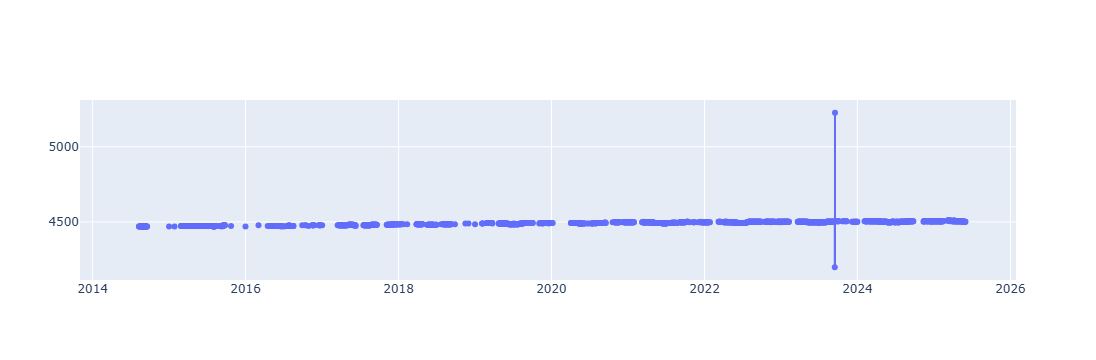

In [53]:
go.Figure(go.Scatter(x=datesMerging['LA12AV'][0]['Дата'], y=datesMerging['LA12AV'][0]['max'], line_shape='hv', 
                                    mode='lines+markers'))

In [87]:
from itertools import groupby
def remove_long_runs(k):
    for name in datasets.keys():
        x = pd.read_csv('dates.txt', header=None, names=['Дата'])
        x = x.merge(datasets[name][0], on = 'Дата', how= 'left')
        lst = list(x[['Дата']][x['Дата'].isin(datasets[name][0]['Дата']) == False].index)
        out = []
        for _, grp in groupby(enumerate(lst), key=lambda t: t[1] - t[0]):
            run = [v for _, v in grp]      
            if len(run) < k:              
                out.extend(run)
        for i in out:
            x.at[i, 'max'] = x.at[i-1, 'max'] 
            x.at[i, 'min'] = x.at[i-1, 'min'] 
            x.at[i, 'avr'] = x.at[i-1, 'avr']
        x.to_csv(f'-{name}-.csv', index = False)

In [ ]:
remove_long_runs(k=6)

In [76]:
def save_to_check():
    listEmptyDates = defaultdict(list)
    for name in empty_files:
        listEmptyDates[name].append(datasets[name][0][['Дата']][datasets[name][0]['max'].isna() == True])
    with pd.ExcelWriter('emptyDates.xlsx', engine='openpyxl') as writer:
        for name in empty_files:
            listEmptyDates[name][0].to_excel(writer, sheet_name=f"{name}", index=False)
            

In [77]:
save_to_check()

In [40]:
def combine_csv():
    datasets_empty = defaultdict(list)
    file_names = easygui.fileopenbox(filetypes="*.txt",multiple=True)
    for name in file_names:
        datasets_empty[f'{name.split('-')[1]}'].append(pd.read_csv(name))
    for name in datasets_empty:
        df_filled = (datasets[name][0].set_index('Дата').combine_first(datasets_empty[name][0].set_index('Дата')).reset_index())
        df_filled.to_csv(f'Новая папка/-{name}-.csv', index = False)

In [51]:
combine_csv()

In [127]:
files = easygui.fileopenbox(filetypes="*.txt",multiple=True)
for name in files:
    x = pd.read_csv('dates(3).txt', header=None, names=['Дата'])
    csv = pd.read_csv(name)
    x = x.merge(csv, on = 'Дата', how= 'left')
    x.to_csv(f'data for ML\\-{name.split('-')[1]}-.csv', index = False)

## Creating csv and adding to existing csv

In [23]:
dictionary_csv = defaultdict(list)
dictionary_txt = defaultdict(list)
def openWays():
    directory = filedialog.askdirectory() #ОТКРЫТИЕ ПАПКИ (ВЫВЕДЕТ ПУТЬ К ПАПКЕ)
    directory1 = []
    directory2 = []
    for root, dirs, files in os.walk(directory):
        for name in files:
            if name.endswith(".csv"):
                directory1.append(os.path.join(root, name))
            if name.endswith(".txt"):
                directory2.append(os.path.join(root, name))
    for name in directory1:
        csv = pd.read_csv(name)
        dictionary_csv[name.split('\\')[-1].split('.')[0]].append(csv)
    for name in directory2:
        appendix = pd.read_csv(name, sep = '\t',header = 1).columns[0].split(' ')[2]
        txt = pd.read_csv(name, sep = '\t', header = 2)
        txt.rename(columns = {'Дата Время         ':'Дата и Время'}, inplace = True)
        txt['Дата'] = txt['Дата и Время'].apply(lambda x:x.split(' ')[0])
        txt['Дата'] = pd.to_datetime(txt['Дата'], dayfirst=True).dt.date
        txt['Значение'] = txt['Значение'].replace(',','.', regex=True).astype('float64')
        df = pd.DataFrame(columns = 'max min avr'.split(' '))
        df['max'] = txt.groupby(by=['Дата'],sort = False )[['Значение']].max()
        df['min'] = txt.groupby(by=['Дата'],sort = False )[['Значение']].min()
        df['avr'] = txt.groupby(by=['Дата'],sort = False )[['Значение']].mean().round(2)
        dictionary_txt[appendix].append(df)

In [24]:
openWays()

In [25]:
for x in list(dictionary_txt.keys()):
    dictionary_txt[x][0] = dictionary_txt[x][0].reset_index()

In [29]:
dictionary_csv = defaultdict(list)
directory = easygui.fileopenbox(filetypes="*.txt",multiple=True)
for name in directory:
    csv = pd.read_csv(name)
    dictionary_csv[name.split('-')[1]].append(csv)

In [28]:
for x in list(dictionary_txt.keys()):
    pd.concat([dictionary_csv[x][0], dictionary_txt[x][0]]).to_csv(f'{x}.csv', index = False)

In [ ]:
dictionary_csv

In [ ]:
dictionary_txt

### Na filling

In [33]:
updateTWT = easygui.fileopenbox(filetypes="*.txt",multiple=True)

In [79]:
dictionary_NaN = defaultdict(list)
for name in updateTWT:
    x = pd.read_csv('date.csv')
    x = x.merge(pd.read_csv(name), on = 'Дата', how= 'left')
    lst = list(x[['Дата']][x['Дата'].isin(pd.read_csv(name)['Дата']) == False].index)
    if len(lst) > 0:
        for i in lst:
            x.iloc[[int(i)],1] = x.iloc[[int(i)-1],1]
            x.iloc[[int(i)],2] = x.iloc[[int(i)-1],2]
            x.iloc[[int(i)],3] = x.iloc[[int(i)-1],3]
    x['max'] = [round(x,2) for x in x['max'].astype('float64')]
    x['min'] = [round(x,2) for x in x['min'].astype('float64')]
    x['avr'] = [round(x,2) for x in x['avr'].astype('float64')]
    dictionary_NaN[name.split('\\')[-1].split('.')[0]].append(x)

## TWT current sum

In [141]:
TWT = easygui.fileopenbox(filetypes="*.txt",multiple=True)

In [139]:
z = pd.DataFrame(columns = ['date','max'])
max_value = float(np.arange(0,3987)[0])
z['date'] = pd.read_csv('date.csv')
for x in list(dictionary_NaN.keys()):
    max_value += np.array(dictionary_NaN[x][0]['max'])
    #print(x.split('\\')[-1].split('.')[0], len(pd.read_csv(x)['max']))
z['max'] = max_value/2

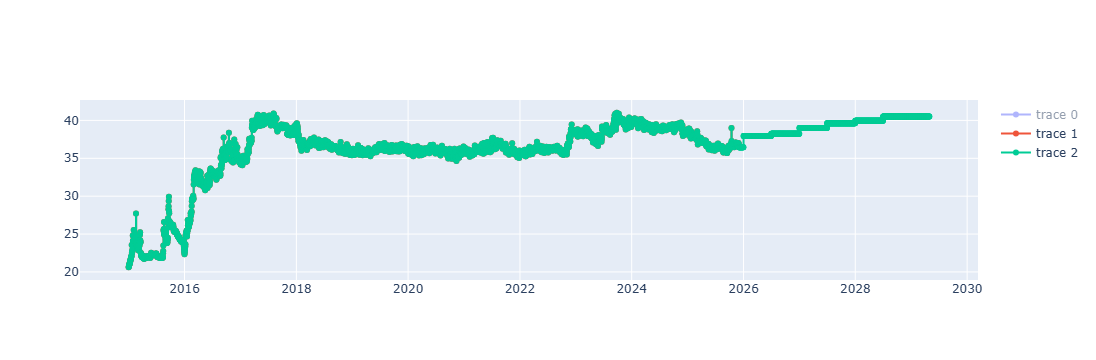

In [168]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=pd.read_csv(TWT[0])['date'], y=pd.read_csv(TWT[0])['max'], line_shape='hv', mode='lines+markers'))
fig.add_trace(go.Scatter(x=z['date'], y=z['max'], line_shape='hv', mode='lines+markers'))
fig.add_trace(go.Scatter(x=pd.concat([z, pd.read_csv(TWT[0])[3987:]])['date'], 
                         y=pd.concat([z, pd.read_csv(TWT[0])[3987:]])['max'], line_shape='hv', mode='lines+markers'))

In [170]:
pd.concat([z, pd.read_csv(TWT[0])[3987:]])[3987:]

,date,max
3987,2025-12-01,36.45
3988,2025-12-02,36.45
3989,2025-12-03,36.45
3990,2025-12-04,36.45
3991,2025-12-05,36.45
...,...,...
5228,2029-04-25,40.50
5229,2029-04-26,40.50
5230,2029-04-27,40.50
5231,2029-04-28,40.50


In [151]:
z

,date,max
0,2015-01-01,20.620
1,2015-01-02,20.690
2,2015-01-03,20.775
3,2015-01-04,20.835
4,2015-01-05,20.940
...,...,...
3982,2025-11-26,36.730
3983,2025-11-27,36.705
3984,2025-11-28,36.840
3985,2025-11-29,37.005


In [39]:
z = pd.read_csv('C:\\Users\\sadykpayev\\Desktop\\Джуниор\\К3\\СТР\\Моделирование СТР в случае отказа двух ЖК\\data (csv)\\Parameters\\Т13КО.csv')
k = pd.read_csv('date.csv')

In [40]:
z['date'] = k['Дата']

In [41]:
z[z['Дата']!=z['date']]

,Дата,max,min,avr,date
